In [129]:
%matplotlib nbagg
import re
import pandas as pd
import numpy as np

In [45]:
import os
galv_only_path = r"C:\Users\engs2608\OneDrive - Nexus365\Documents\MG39402 - Benchmarking rate capability testing protocols\ElectrochemistryFocus\Electrochemistry_data\ICI\ici_data\galv_only"

challenge_fname = 'LiS58B_260115_ICI_cell2_005C_Galvonly_CE4.mpt.txt'
challenge_filename = os.path.join(galv_only_path, challenge_fname)

working_fname = 'LiS58A_260128_ICI_02C_GalvOnly_CF2.mpt'
working_filename = os.path.join(galv_only_path, working_fname)

In [185]:
class BiologicData(object):
    def __init__(self, filename):
        
        import re
        import pandas as pd
        import numpy as np
               
        data_read = []
        
        self.version = "2.1.0"
        self._change_log = ["2.0.1    251204    added self._current_column and self._voltage_column for outputs from EC lab vs BT lab, added np.nan for empty cycles",
                            "2.0.2     260413    added 'if 'mode' not in line' when making self._df to avoid files with repeated headers",
                            "2.1.0     260414    added removing skipped cycles in init. Previously, some files returned to cycle 0 midway, unclear why"]

        with open(filename) as f:
            for line in f.readlines():
                if "Nb header lines" in line:
                    header_lines = int(re.findall("\d+", line)[0])
                data_read.append(line.strip("\n").split("\t"))
                
        header_labels = data_read[header_lines-1]
        
        df = pd.DataFrame(np.array([line for line in data_read[header_lines:] if "mode" not in line], ## Added 13/04/2026 ## removed self._df 14/04/2026
                                         dtype=float), columns=header_labels[:-1])
        
        from copy import deepcopy
        self._df = df ## added 14/04/2026
        
        ## Removing skipped cycles: added 14/04/2026        
        self.df = df.loc[df["I/mA"]!=0].reset_index(drop=True)

        cycle_numbers = self.df["cycle number"].to_numpy()
        skip_points = cycle_numbers[1:]<cycle_numbers[:-1]

        if any(skip_points==True) == True:

            cycle_number_breaks = np.argwhere(skip_points)[0]+1 ## +1 because of offset

            cycle_number_breaks = [n for n in cycle_number_breaks if n>1]

            for break_point in cycle_number_breaks:
                previous_cycle_number = self.df["cycle number"].iloc[break_point-1]
                apparent_cycle_number = self.df["cycle number"].iloc[break_point]
                number_gap = previous_cycle_number-apparent_cycle_number
                self.df = self.df.copy()

                previous_time = self.df["time/s"].iloc[break_point-1]
                apparent_time = self.df["time/s"].iloc[break_point]
                time_gap = previous_time-apparent_time

                self.df.loc[break_point:, "cycle number"] = self.df.loc[break_point:, "cycle number"]+1+number_gap
                self.df.loc[break_point:, "time/s"] = self.df.loc[break_point:, "time/s"]+time_gap
        
        
        self.number_cycles = int(self.df["cycle number"].max())
        
        if "I/mA" in self._df.columns:
            self._current_column = "I/mA"
        elif "<I>/mA" in self._df.columns:
            self._current_column = "<I>/mA"
            
        if "Ecell/V" in self._df.columns:
            self._voltage_column = "Ecell/V"
        elif "Ewe/V" in self._df.columns:
            self._voltage_column = "Ewe/V"
        
        class _Cycle(object):
            def __init__(cycle_self):
                cycle_self_keys = ["capacity", "voltage", "summary_capacity"]
                cycle_self.__dict__.update([(keys, []) for keys in cycle_self_keys])
            
        cycle_types = {"charge": 1,
                       "discharge": 0}
        
        data_types = {"capacity": "Capacity/mA.h",
                      "voltage": self._voltage_column, 
                      }
        
        for cycle_type in cycle_types.keys():
            setattr(self, cycle_type, _Cycle()) 
        
        ## Changed output to numpy rather than pd.Series
        for ncyc in range(self.number_cycles):
            cycle_df = self.df.loc[(self.df["cycle number"]==ncyc) & (abs(self.df[self._current_column])>0)]
            
            for cycle_keys, cycle_values in cycle_types.items():
                cycle_capacity = cycle_df.loc[cycle_df["ox/red"]==cycle_values][data_types["capacity"]]
                vars(self)[cycle_keys].capacity.append((cycle_capacity-cycle_capacity.min()).to_numpy())
                
                vars(self)[cycle_keys].voltage.append(cycle_df.loc[cycle_df["ox/red"]==cycle_values][data_types["voltage"]].to_numpy())           
                if len(vars(self)[cycle_keys].capacity[-1]) > 0:
                    vars(self)[cycle_keys].summary_capacity.append(max(vars(self)[cycle_keys].capacity[-1]))
                else:
                    vars(self)[cycle_keys].summary_capacity.append(np.nan)

In [186]:
working = BiologicData(working_filename)

In [187]:
challenge = BiologicData(challenge_filename)
self = challenge

<IPython.core.display.Javascript object>


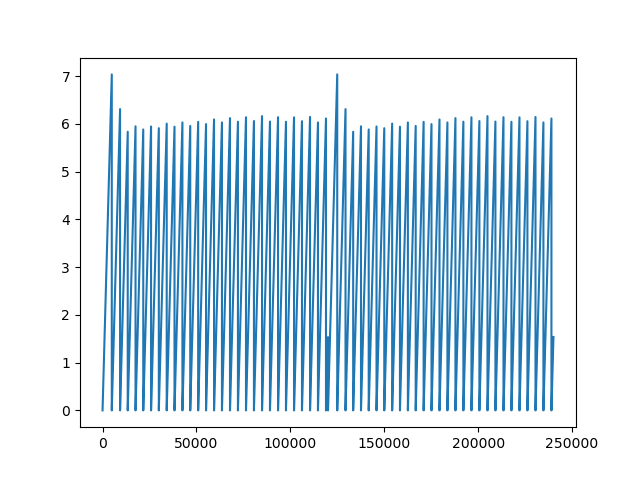

In [188]:
fig, ax = plt.subplots()
ax.plot(self.df["Capacity/mA.h"])

In [189]:
capacity = self.discharge.capacity[0]
all(capacity[1:]>capacity[:-1])

True

In [190]:
np.argwhere(capacity[1:]<=capacity[:-1])

array([], shape=(0, 1), dtype=int64)

In [191]:
capacity.shape

(4919,)

<IPython.core.display.Javascript object>


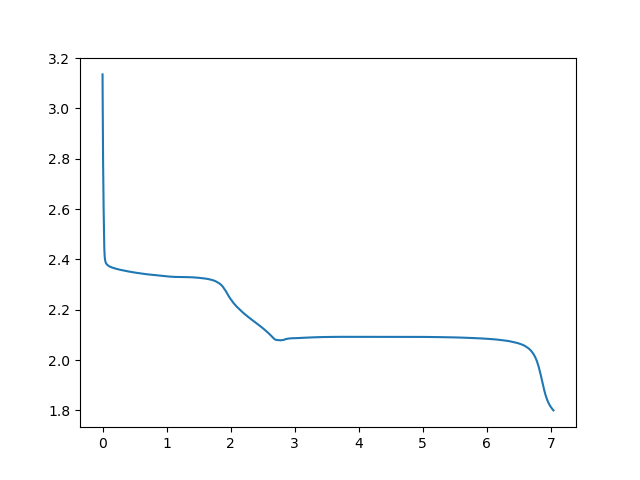

[]

In [192]:
fig, ax = plt.subplots()
ax.plot(self.discharge.capacity[0], self.discharge.voltage[0])
ax.plot()

In [170]:
self.discharge.capacity

<__main__.SimpleLoad.__init__.<locals>._Cycle at 0x219bca7e050>

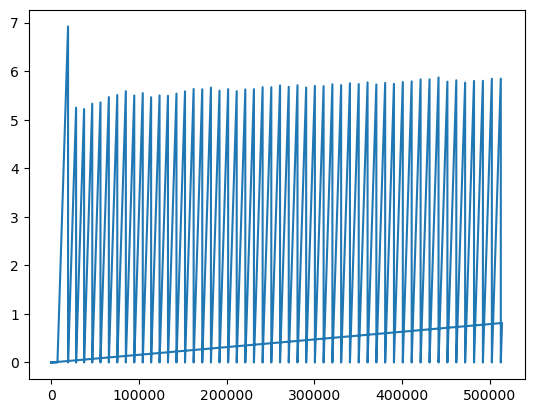

In [57]:
fig, ax = plt.subplots()
ax.plot(working.df["time/s"], working.df["Capacity/mA.h"])

In [17]:
current_column = 'I/mA'

cycle_types = {"charge": 1,
               "discharge": 0}

data_types = {"capacity": "Capacity/mA.h",
              "voltage": 'Ecell/V', 
              }

In [36]:
capacity = []
voltage = []
summary_capacity = []
cycle_split_diag = []

for ncyc in range(number_cycles):
    print(ncyc)
    cycle_df = df.loc[(df["cycle number"]==ncyc) & (abs(df[current_column])>0)]
    print(cycle_df.index[0], cycle_df.index[-1])
    cycle_split_diag.append(cycle_df)
    for cycle_keys, cycle_values in cycle_types.items():
        if cycle_keys == "discharge":
            cycle_capacity = cycle_df.loc[cycle_df["ox/red"]==cycle_values][data_types["capacity"]]
            capacity.append((cycle_capacity-cycle_capacity.min()).to_numpy())

            voltage.append(cycle_df.loc[cycle_df["ox/red"]==cycle_values][data_types["voltage"]].to_numpy())           
            if len(capacity[-1]) > 0:
                summary_capacity.append(capacity[-1])
            else:
                summary_capacity.append(np.nan)

0
720 126403
1
5639 134892
2
14128 143162
3
22398 151449
4
30685 159800
5
39036 168179
6
47415 176593
7
55829 185067
8
64303 193571
9
72807 202098
10
81334 210633
11
89869 219150
12
98386 227673
13
106909 236183


In [44]:
## 1. check whether data is continous

all(df["time/s"].to_numpy()[1:]>df["time/s"].to_numpy()[:-1])

False

In [40]:
cycle_split_diag[0].columns

Index(['mode', 'ox/red', 'error', 'control changes', 'Ns changes',
       'counter inc.', 'Ns', 'I Range', 'time/s', 'control/mA', 'Ecell/V',
       'I/mA', 'dq/mA.h', '(Q-Qo)/mA.h', 'Q charge/discharge/mA.h',
       'half cycle', 'Energy charge/W.h', 'Energy discharge/W.h',
       'Capacitance charge/ F', 'Capacitance discharge/ F', 'step time/s',
       'Energy/W.h', 'x', 'Q discharge/mA.h', 'Q charge/mA.h', 'Capacity/mA.h',
       'Efficiency/%', 'cycle number', 'P/W', 'R/Ohm'],
      dtype='object')

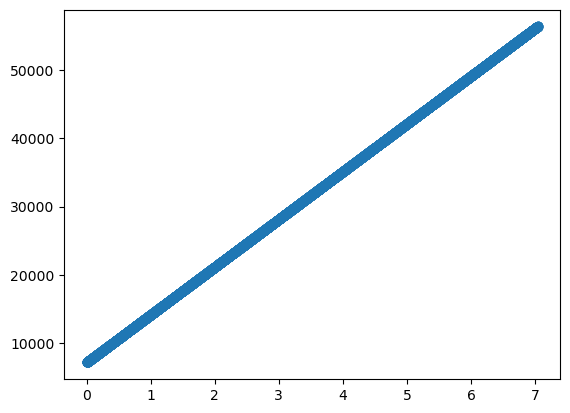

In [41]:
fig, ax = plt.subplots()
ax.plot(cycle_split_diag[0]["Capacity/mA.h"], cycle_split_diag[0]["time/s"], "-o")

In [27]:
capacity = df.loc[df["cycle number"]==0]["Capacity/mA.h"]

In [24]:
import matplotlib.pyplot as plt

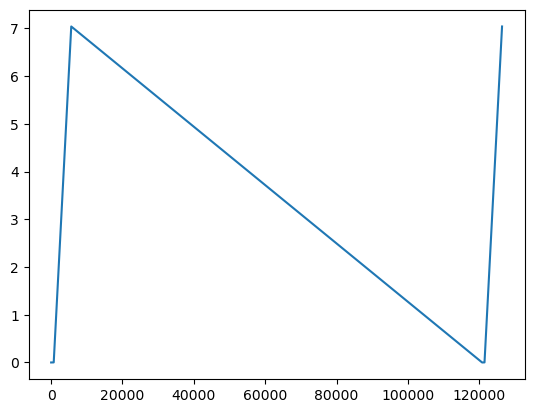

In [28]:
fig, ax = plt.subplots()
ax.plot(capacity)